# 3.2 Finding a cycle you were not told about

Lesson 3 subtracted cycles you already knew were there: a day has 24 hours and a week has
seven days, so you knew what period to give the decomposition. This notebook is for when you
do not — when the data has a rhythm and nobody has told you how long it is.

Three tools, in the order you would actually reach for them:

1. **Autocorrelation** — correlate the series with a shifted copy of itself. The shift that
   correlates best is the length of the cycle.
2. **Decomposition** with that period, which is lesson 3's move again, now with the period
   measured rather than assumed.
3. **Fourier transforms**, for when the pattern is not one cycle but several at once.

The last of them arrives because the first two fail on the second dataset, and the way they
fail is the more useful half of this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from goad_toolkit.config import FileConfig
from goad_toolkit.filehandler import FileHandler
from goad_toolkit.visualizer import ACFPlot, DecomposePlot, PlotSettings
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf

Let's make some synthetic data. We will create:

- 3 years of data
- with 4 seasonal cycles per year
- we add a trend of +10 over the full period
- and we add some noise

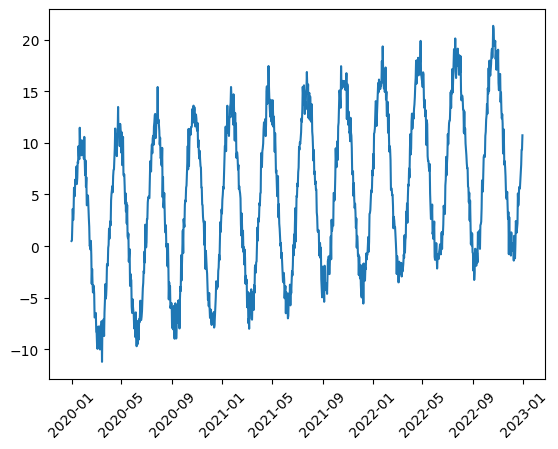

In [2]:
# Generate a date range
years = 3
dates = pd.date_range(start="2020-01-01", periods=365 * years, freq="D")

# Generate synthetic data with seasonality
cycles = 4
np.random.seed(42)
trend = np.linspace(0, 10, len(dates))  # Linear trend
seasonality = 10 * np.sin(
    np.linspace(0, cycles * years * 2 * np.pi, len(dates))
)  # Yearly seasonality
noise = np.random.normal(0, 1, len(dates))  # Random noise
synthetic_data = trend + seasonality + noise

synthetic = pd.DataFrame({"Date": dates, "Value": synthetic_data}).set_index("Date")
plt.plot(synthetic.index, synthetic["Value"])
plt.xticks(rotation=45)
plt.show()

Autocorrelation, often visualized through Time Series Autocorrelation Plots (tsaplots), is a statistical measure used to determine the degree of similarity between a time series and a lagged version of itself over successive time intervals. It's essentially measuring how well the current values of the series are related to its past values. This relationship is quantified as a correlation coefficient, ranging from -1 to 1, where:

- 1 indicates a perfect positive correlation: as the time series increases (or decreases), the lagged series also increases (or decreases).
- -1 indicates a perfect negative correlation: as the time series increases, the lagged series decreases, and vice versa.
- 0 indicates no correlation: the time series and its lagged version do not show any linear relationship.

Motivation to Use Autocorrelation

1. Identifying Seasonality: One of the primary uses of autocorrelation plots is to identify seasonal patterns within time series data. If a time series is influenced by seasonality, the autocorrelation plot will exhibit regular, significant peaks at lags corresponding to the season's length. For example, a yearly seasonal pattern would show peaks at multiples of the seasonal period (e.g., every 12 months for monthly data).

2. Model Selection: Autocorrelation plots are invaluable in the model selection process for time series analysis. They help determine the appropriate type of models to fit the data, such as ARIMA (AutoRegressive Integrated Moving Average), by identifying the order of autoregressive (AR) or moving average (MA) components needed to capture the time series dynamics.

3. Data Preprocessing: By understanding the autocorrelation structure of a dataset, analysts can make informed decisions about data preprocessing steps, such as differencing or transformation, to make the series stationary—a common requirement for many time series modeling techniques.

4. Detecting Anomalies: Autocorrelation plots can also help in detecting anomalies or unusual patterns in the time series data that might not be apparent from simply looking at the time series plot. Significant deviations from the expected autocorrelation pattern can indicate outliers, structural breaks, or changes in the underlying process generating the series.

/Users/rgrouls/code/courses/goad_toolkit/src/goad_toolkit/visualizer.py:1012: FutureWarning: acf currently returns a plain tuple whose length depends on the qstat and alpha arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an AcfResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  values, confint = acf(series, nlags=nlags, alpha=alpha, fft=True)  # type: ignore


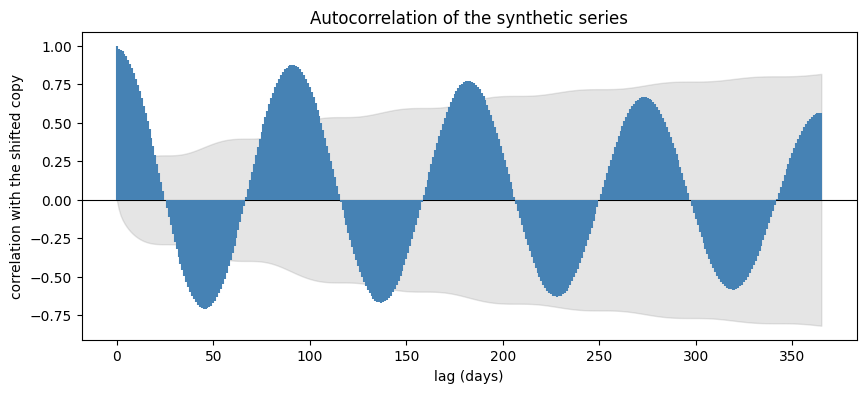

In [3]:
settings = PlotSettings(
    figsize=(10, 4),
    title="Autocorrelation of the synthetic series",
    xlabel="lag (days)",
    ylabel="correlation with the shifted copy",
)
fig, ax = ACFPlot(settings).plot(data=synthetic["Value"], nlags=365)

The cycle we built is right there: a peak at about 90 days, which is what four cycles a year
means. The grey band is the interval inside which a correlation is indistinguishable from
zero, so lags poking out of it are the ones worth reading.

Lag 0 is always 1.0 — a series correlates perfectly with itself — and the first few lags are
high for a boring reason: yesterday's value is close to today's. So to find the *cycle* you
skip the first stretch and take the largest correlation after it.

In [4]:
acf_values = acf(synthetic["Value"], nlags=365, fft=True)
skip = 50
lag = int(np.argmax(acf_values[skip:])) + skip
print(f"strongest lag after the first {skip}: {lag} days (r = {acf_values[lag]:.2f})")
print(f"we built the series with {cycles} cycles per year, so we expected "
      f"{round(365 / cycles)} days")

strongest lag after the first 50: 91 days (r = 0.88)
we built the series with 4 cycles per year, so we expected 91 days


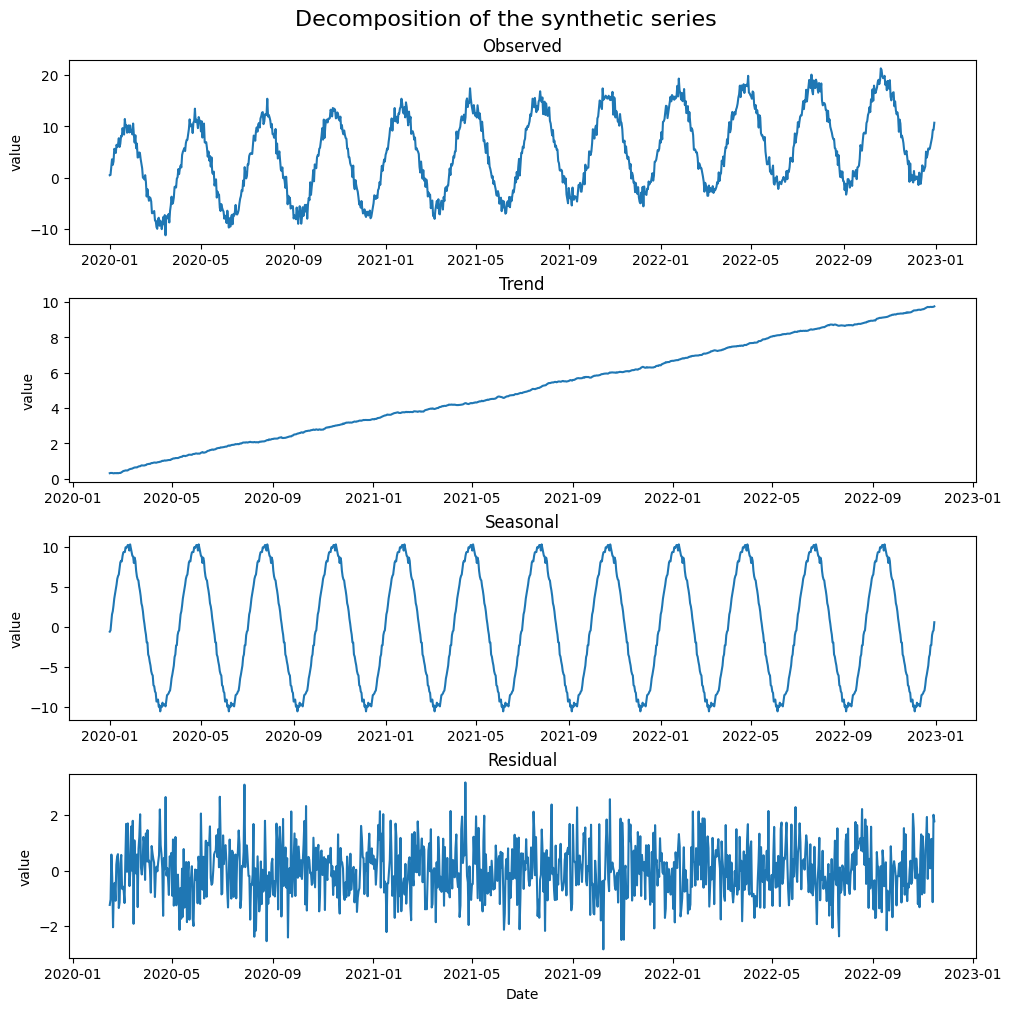

In [5]:
settings = PlotSettings(
    figsize=(10, 10),
    title="Decomposition of the synthetic series",
    xlabel="",
    ylabel="value",
    max_cols=1,
)
fig = DecomposePlot(settings).plot(data=synthetic, column="Value", period=lag)
# Seaborn fills an empty xlabel with the index name, so every panel repeats "date" —
# straight into the title of the panel below it. Keep it on the bottom one only.
for panel in fig.axes[:-1]:
    panel.set_xlabel("")

That is a deconstruction of how we built the series: a straight trend, a repeating wave, and
noise. Note the period came from the measurement above, not from us knowing the answer.

Subtracting the first two leaves what the model could not explain:

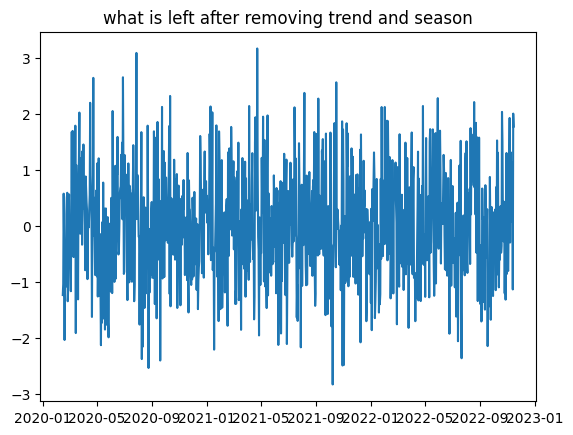

the residual keeps 1.7% of the variance; we put in noise with a variance of 0.95


In [6]:
result = seasonal_decompose(synthetic["Value"], model="additive", period=lag)
residual = synthetic["Value"] - result.seasonal - result.trend
plt.plot(residual)
plt.title("what is left after removing trend and season")
plt.show()
print(f"the residual keeps {residual.var() / synthetic['Value'].var():.1%} of the "
      f"variance; we put in noise with a variance of {noise.var():.2f}")

## 3.3 Sunspots, where all of this breaks

Monthly sunspot counts from 1749 to now, published by the Royal Observatory of Belgium. The
solar cycle is roughly eleven years, which is long enough that nobody would guess it from
looking, and famous enough that we can check the answer.

The download goes through goad's `FileHandler` rather than a bare `requests.get`, for one
reason worth having: it writes the file to `~/.cache/mads-dav/raw` and does not download it
again. A notebook that re-fetches on every run is a notebook that fails in a room with bad
wifi, and it is rude to the server.

2026-09-01 17:41:39.403 | INFO     | goad_toolkit.filehandler:download:86 - /Users/rgrouls/.cache/mads-dav/raw/sunspots.txt already exists
Remove file to download again


3,331 monthly observations, 1749 to 2026


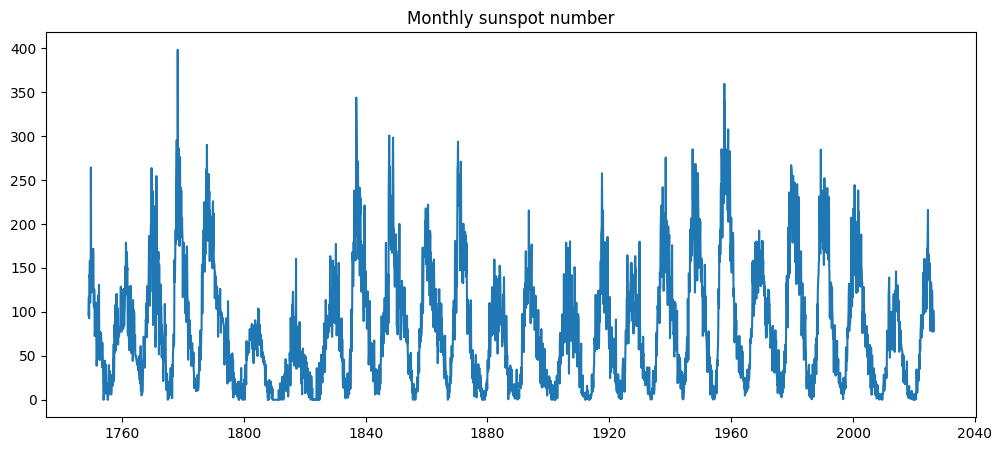

In [7]:
config = FileConfig(
    data_dir=Path.home() / ".cache/mads-dav",
    filename=Path("sunspots.txt"),
    url="https://www.sidc.be/SILSO/DATA/SN_m_tot_V2.0.txt",
    date_column=None,
)
handler = FileHandler(config)
handler.download()

# `FileHandler.load` reads .csv and .parquet; this one is whitespace-separated with no
# header, so we read it ourselves and only use the handler for the fetching and caching.
sunspots = pd.read_csv(
    config.data_dir / "raw" / config.filename,
    sep=r"\s+",
    header=None,
    names=["year", "month", "decimal_date", "sunspots", "std_dev", "observations",
           "definitive"],
)
sunspots["date"] = pd.to_datetime({"year": sunspots.year, "month": sunspots.month, "day": 1})  # ty: ignore[no-matching-overload]
sunspots = sunspots.set_index("date")
print(f"{len(sunspots):,} monthly observations, {sunspots.index.min():%Y} to "
      f"{sunspots.index.max():%Y}")

plt.figure(figsize=(12, 5))
plt.plot(sunspots.index, sunspots["sunspots"])
plt.title("Monthly sunspot number")
plt.show()

/Users/rgrouls/code/courses/goad_toolkit/src/goad_toolkit/visualizer.py:1012: FutureWarning: acf currently returns a plain tuple whose length depends on the qstat and alpha arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an AcfResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  values, confint = acf(series, nlags=nlags, alpha=alpha, fft=True)  # type: ignore


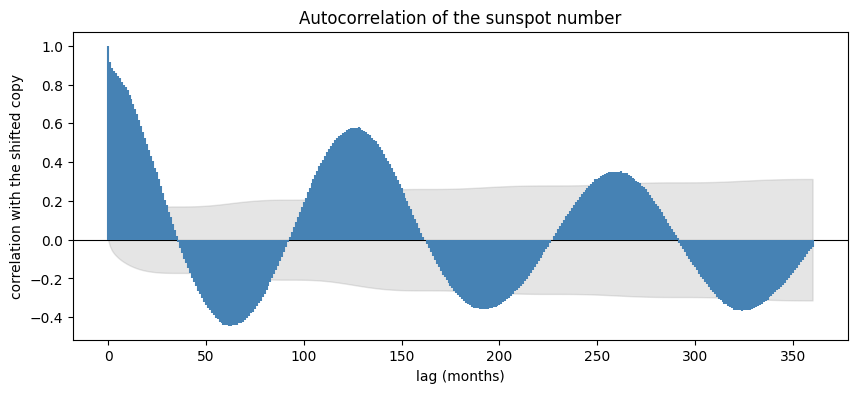

In [8]:
settings = PlotSettings(
    figsize=(10, 4),
    title="Autocorrelation of the sunspot number",
    xlabel="lag (months)",
    ylabel="correlation with the shifted copy",
)
fig, ax = ACFPlot(settings).plot(data=sunspots["sunspots"], nlags=30 * 12)

In [9]:
acf_values = acf(sunspots["sunspots"], nlags=365, fft=True)
skip = 50
solar_lag = int(np.argmax(acf_values[skip:])) + skip
print(f"strongest lag after the first {skip}: {solar_lag} months "
      f"= {solar_lag / 12:.1f} years (r = {acf_values[solar_lag]:.2f})")

strongest lag after the first 50: 128 months = 10.7 years (r = 0.58)


10.7 years, from a method that knows nothing about the sun. The published figure is about
eleven, so the measurement is right — and this is the one moment in this notebook where you
can check a data-derived number against the outside world. Take the win, then watch what
happens when we hand it to the decomposition.

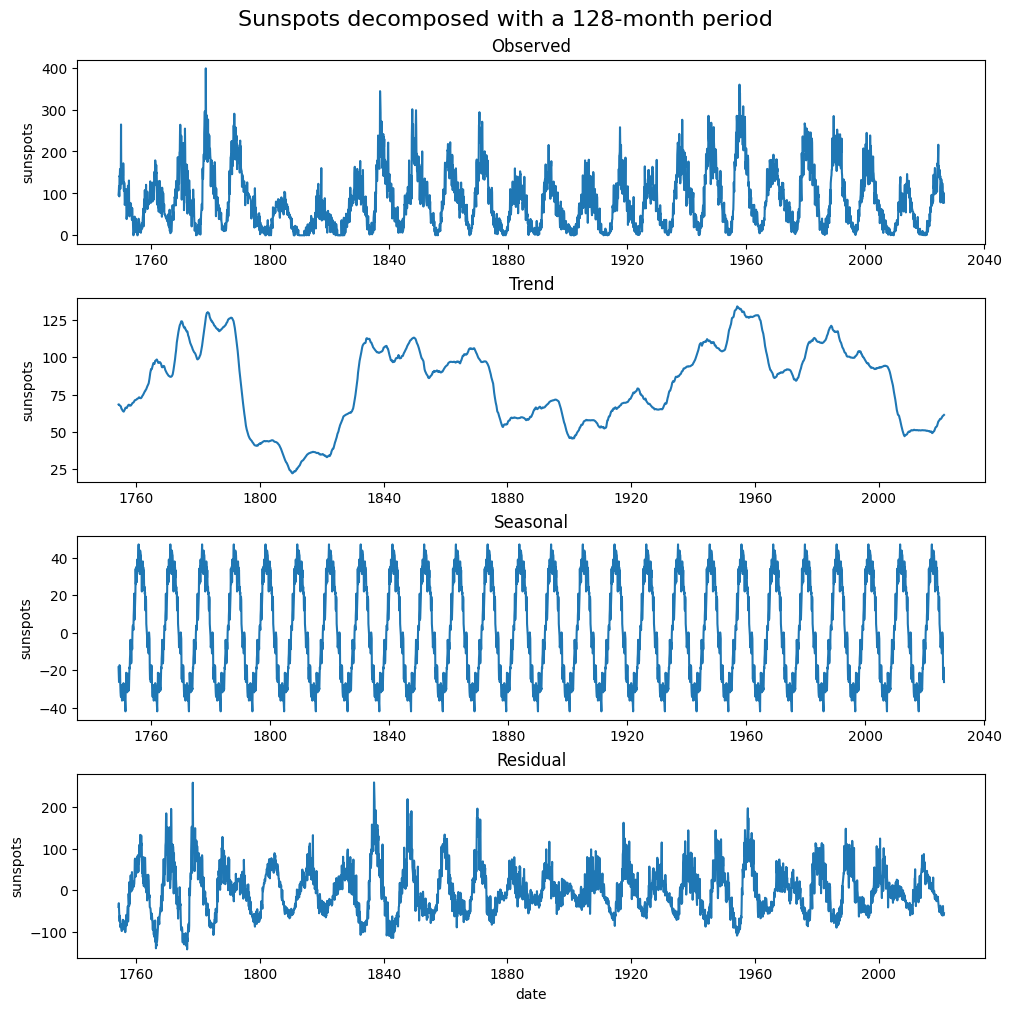

In [10]:
settings = PlotSettings(
    figsize=(10, 10),
    title=f"Sunspots decomposed with a {solar_lag}-month period",
    xlabel="",
    ylabel="sunspots",
    max_cols=1,
)
fig = DecomposePlot(settings).plot(data=sunspots, column="sunspots", period=solar_lag)
# Seaborn fills an empty xlabel with the index name, so every panel repeats "date" —
# straight into the title of the panel below it. Keep it on the bottom one only.
for panel in fig.axes[:-1]:
    panel.set_xlabel("")

In [11]:
rows = []
for period in (solar_lag, 365):
    result = seasonal_decompose(sunspots["sunspots"], model="additive", period=period)
    residual = result.resid.dropna()
    residual_acf = acf(residual, nlags=200, fft=True)
    residual_lag = int(np.argmax(residual_acf[skip:])) + skip
    rows.append({
        "period (months)": period,
        "= years": round(period / 12, 1),
        "residual variance": residual.var() / sunspots["sunspots"].var(),
        "residual's own strongest lag": residual_lag,
        "r at that lag": round(residual_acf[residual_lag], 2),
    })
print(pd.DataFrame(rows).to_string(index=False,
                                   formatters={"residual variance": "{:.1%}".format}))

 period (months)  = years residual variance  residual's own strongest lag  r at that lag
             128     10.7             69.1%                           123           0.52
             365     30.4             72.2%                           128           0.49


Read the second column. **The residual keeps about seventy percent of the variance, and it
still has an eleven-year cycle in it** — the thing we just subtracted is still there, at a
correlation of 0.5, which is barely weaker than in the raw series.

That is not a badly chosen period. The second row uses 365 months — thirty years, a period
nobody would defend — and it lands three points away. `seasonal_decompose` fails here for a reason no
parameter fixes: it averages every 128th observation together and calls that "the season",
which assumes each cycle is the *same length and the same shape* as the last. Solar cycles
run anywhere from nine to fourteen years and rise faster than they fall. Average them and you
get a smear that fits none of them.

So the honest report is: the period is real and measurable, the decomposition is the wrong
tool for it. Which is why the next section exists — a method that does not assume one cycle
of one length.

> The general lesson, and it is the same one as lesson 3's rolling windows: **a method that
> runs without complaining has not agreed with you.** `seasonal_decompose` returned four
> tidy panels for both periods. Only checking the residual showed that one of them was a
> failure and so was the other.

## 3.4 Fourier transforms

In [12]:
import numpy as np
import pandas as pd
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

Because the patterns are more complex in this timeseries, we will take another approach, using Fourier Transforms. The main idea behind the fourier transform is this: any complex pattern can be broken down into a series of sine waves, and the Fourier transform is a way to do this.

The fourier transform takes a complex pattern and breaks it down into a series of sine waves of different frequencies and amplitudes.

We will first illustrate this with our synthetic data

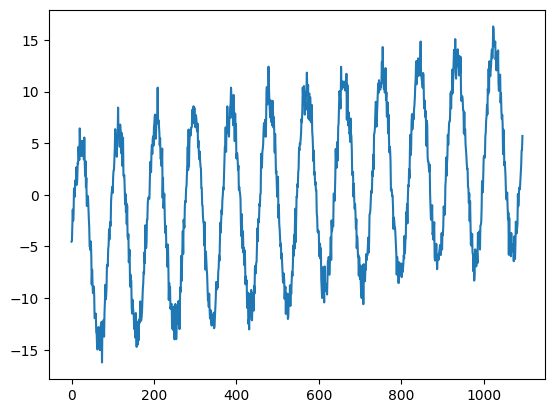

In [13]:
y = synthetic_data.copy()
y -= y.mean()
plt.plot(y)

In [14]:
def fourier_model(timeseries, k):
    # Calculate the number of data points in the timeseries
    t = 1.0
    n = len(timeseries)
    # Generate a time vector 'x' from 0 to n*t (excluding the endpoint) evenly spaced
    x = np.linspace(0.0, n * t, n, endpoint=False)
    # Perform the Fourier Transform of the timeseries
    yf = fft(timeseries)
    # Generate the frequency bins for the first half of the Fourier Transform result
    # This represents the positive frequencies up to the Nyquist frequency
    # the nyquist frequency is the highest frequency that can be represented in the fourier transform
    # it is half of the sampling frequency
    xf = fftfreq(n, t)[: n // 2]
    # Identify indices of the 'k' largest frequencies by their magnitude in the first half of the Fourier spectrum
    # the largest frequencies are the most important components of the signal
    indices = np.argsort(np.abs(yf[0 : n // 2]))[-k:]
    # Extract the frequencies corresponding to the 'k' largest magnitudes
    frequencies = xf[indices]
    # Calculate the amplitudes of these frequencies as twice the magnitude divided by n
    # This accounts for the symmetry of the Fourier Transform for real signals
    amplitudes = 2.0 / n * np.abs(yf[indices])
    # Extract the phases of these frequencies and adjust by adding pi/2 to align phases
    phases = np.angle(yf[indices]) + 1 / 2 * np.pi
    # Return a dictionary of the model parameters: 'x', 'frequencies', 'amplitudes', 'phases'
    return {
        "x": x,
        "frequencies": frequencies,
        "amplitudes": amplitudes,
        "phases": phases,
    }

This deconstruction gives us the top k with the highest amplitudes (and thus most important) sine waves, with which we can reconstruct (model) the original data. lets visualize our model

In [15]:
def model(parameters):
    # Extract the time vector 'x' from the parameters
    x = parameters["x"]
    # Extract the frequencies, amplitudes, and phases from the parameters
    frequencies = parameters["frequencies"]
    amplitudes = parameters["amplitudes"]
    phases = parameters["phases"]

    # Initialize a zero array 'y' of the same shape as 'x' to store the model output
    y = np.zeros_like(x)

    # Add each sine wave component to 'y' based on the extracted frequencies, amplitudes, and phases
    for freq, amp, phase in zip(frequencies, amplitudes, phases):
        y += amp * np.sin(2.0 * np.pi * freq * x + phase)

    # Return the composite signal 'y' as the sum of the sine wave components
    return y

And compare it with the orginal data

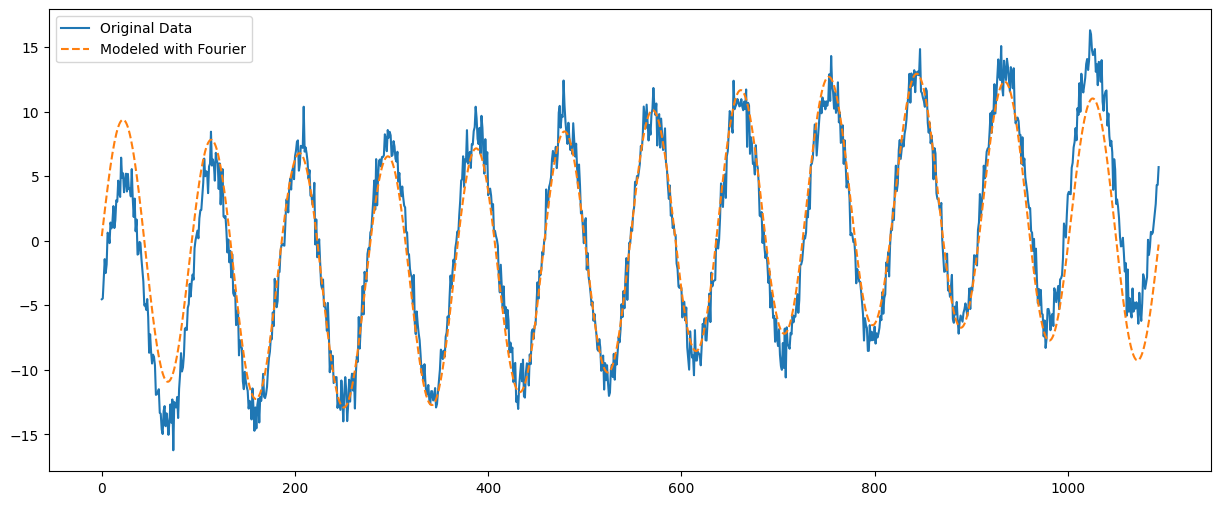

In [16]:
k = 2  # Number of Fourier components

parameters = fourier_model(y, k)
x = parameters["x"]
y_model = model(parameters)


def plot_model(x, y, y_model):
    plt.figure(figsize=(15, 6))
    plt.plot(x, y, label="Original Data")
    plt.plot(x, y_model, label="Modeled with Fourier", linestyle="--")
    plt.legend()
    plt.show()


plot_model(x, y, y_model)


Its not perfect, but pretty good! A nice extra is that we loose most of the noise.
Now, let us try the same with a subset of the sunspots data

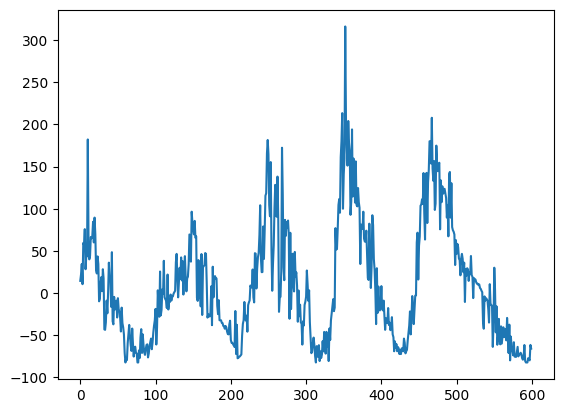

In [17]:
y = sunspots["sunspots"].values.copy()
y -= y.mean()
y = y[: 12 * 50]  # first 50 years
plt.plot(y)  # first 50 years

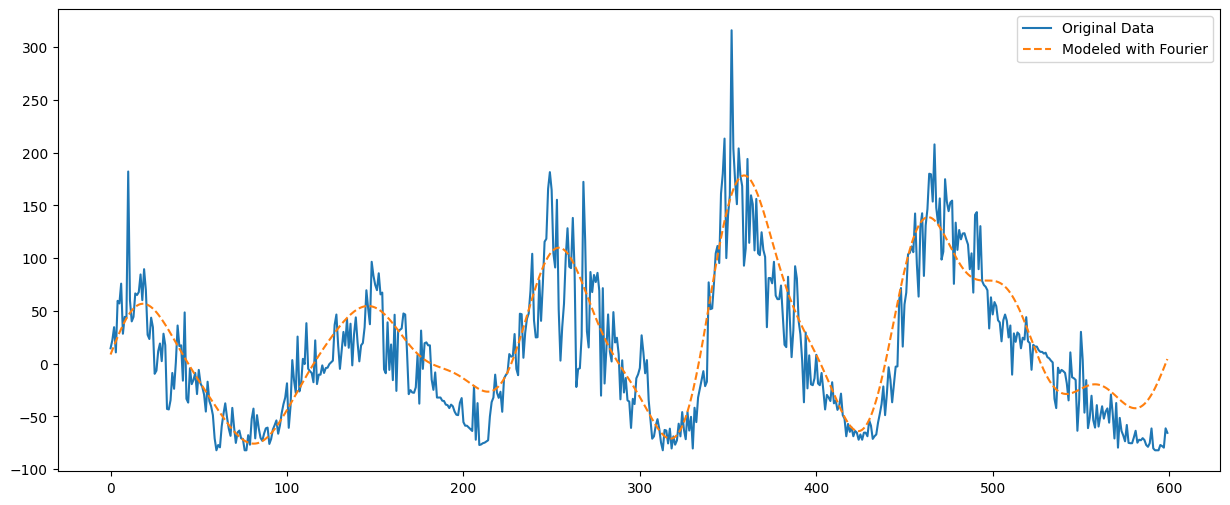

In [18]:
k = 9  # Number of Fourier components

parameters = fourier_model(y, k)
y_model = model(parameters)
x = parameters["x"]
plot_model(x, y, y_model)

While this seems like a nice result, we are probably overfitting the timeseries; it is very unlikely that this model gives us a solid prediction, because as you can see the model overfits on the noise of the data. However, it is a nice illustration of how this can work.

You could improve this model by doing things like:
- reduce the number of sine waves! This will make the model simpler, preventing overfitting
- fitting the model on a trainset (eg 50 years) and testing results on a testset (eg next 50 years)
- removing noise from the data with smoothing techniques
- talking to a domain expert by incorporating domain knowledge
- modelling the slow drift in cycle *height* across centuries, which the decomposition put in its trend
- finding better ways to account for the non-symmetric shape of the data than simply subtracting the mean

Below you will find a short crash course into smoothing; however, this is a course on visualisation so we will only scratch the surface of this topic.
In the course on Machine Learning we will go much deeper into this topic, but we will also let the neural networks figure out what the best filters are. 
Regardless, it can be usefull to do some feature engineering, especially on timeseries.

## 3.5 Smoothing with Scipy filters

1. Savitzky-Golay Filter: This filter essentially fits successive sub-sets of adjacent data points with a low-degree polynomial by the method of linear least squares. It's good for preserving the original shape and features of the signal while smoothing.

2. Low-pass Butterworth Filter: This is a type of signal processing filter designed to have a frequency response as flat as possible in the passband. It's effective in reducing the noise while keeping the sharpness of the signal transitions.

The parameters for filtering techniques like the Savitzky-Golay filter and the Low-pass Butterworth filter are crucial for achieving the desired smoothing effect without significantly distorting the signal. These parameters must be chosen carefully, often based on both the characteristics of the signal (e.g., frequency content, noise characteristics) and empirical testing.

## Types of Filters
### Savitzky-Golay Filter

- Window Size: This is the number of data points used to fit the polynomial. A larger window will result in smoother signals but can also smear out rapid changes. The window size must be odd and large enough to encompass enough points to perform a meaningful fit. Typically, you'd start with a window size that captures the duration of the features of interest in your signal and adjust based on empirical results.

- Polynomial Order: This is the degree of the polynomial used to fit the slices of your data. A higher order can fit the data more closely, but if it's too high, it can lead to overfitting, where the filter starts to follow the noise rather than the underlying signal trend. A good starting point is a low order (e.g., 2 or 3) and increasing it only if the smoothing is not sufficient and the signal's features allow for a more complex fit.
### Low-pass Butterworth Filter

- Cutoff Frequency: This defines the frequency at which the filter starts to attenuate the signal. Frequencies lower than the cutoff pass through largely unchanged, while frequencies higher are reduced. The cutoff frequency should be chosen based on the frequency content of your signal and the noise. For instance, if your signal has important features at low frequencies and noise at high frequencies, you'd set the cutoff just above the highest frequency of interest. It's often expressed as a fraction of the Nyquist frequency (half the sampling rate).

- Filter Order (the parameter 3 in the butter function): This determines the steepness of the filter's transition from passband to stopband. A higher order means a steeper transition but can also lead to more ringing artifacts (Gibbs phenomenon) and phase distortion. A lower order results in a gentler slope. The choice of order is a balance between adequately attenuating noise while minimizing signal distortion. Starting with a low order (e.g., 3 or 4) is common, and then it can be adjusted based on the performance.
## General Guidelines

- Empirical Testing: The best parameters often come from empirical testing and understanding the nature of your signal. Visualization tools (like plotting the filtered signal) are invaluable for assessing the effectiveness of your chosen parameters.
- Signal Characteristics: Consider the characteristics of your signal (e.g., the frequency of interest, the expected shape of the signal, the nature of the noise) when choosing parameters.
- Iterative Approach: Start with general rules of thumb and then iteratively adjust based on the results. Filtering is often more of an art than a science, requiring some experimentation.

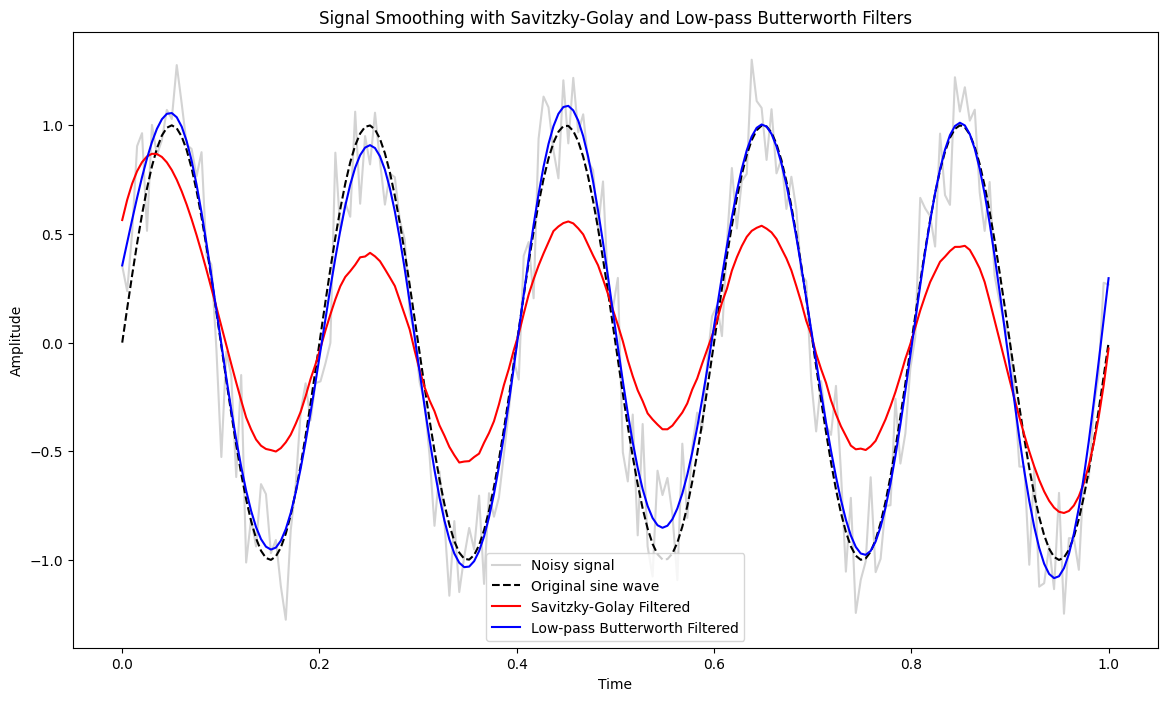

In [19]:
from scipy.signal import savgol_filter, butter, filtfilt

# Generate a noisy sine wave for demonstration
np.random.seed(0)  # For reproducibility
time = np.linspace(0, 1, 200)  # 1 second, 200 samples
frequency = 5  # Frequency of the sine wave
amplitude = 1  # Amplitude of the sine wave
noise = np.random.normal(0, 0.2, time.shape)  # Gaussian noise
sine_wave = amplitude * np.sin(2 * np.pi * frequency * time)
noisy_signal = sine_wave + noise

# Apply Savitzky-Golay filter
window_size = 51  # Window size should be odd
poly_order = 3  # Polynomial order
savitzky_golay_filtered = savgol_filter(noisy_signal, window_size, poly_order)

# Apply Low-pass Butterworth filter
cutoff_frequency = 0.1  # Cutoff frequency as a fraction of the sampling rate
filter_order = 3  # Filter order
b, a = butter(filter_order, cutoff_frequency, btype="low", analog=False)
butterworth_filtered = filtfilt(b, a, noisy_signal)

# Plot the original and filtered signals
plt.figure(figsize=(14, 8))
plt.plot(time, noisy_signal, label="Noisy signal", color="lightgray")
plt.plot(time, sine_wave, label="Original sine wave", linestyle="--", color="black")
plt.plot(time, savitzky_golay_filtered, label="Savitzky-Golay Filtered", color="red")
plt.plot(
    time, butterworth_filtered, label="Low-pass Butterworth Filtered", color="blue"
)
plt.legend()
plt.title("Signal Smoothing with Savitzky-Golay and Low-pass Butterworth Filters")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

## 3.6 What to write down

1. **The period you used, and where it came from** — measured off the autocorrelation, or
   assumed because a week has seven days. Both are fine; confusing them is not.
2. **The residual, checked.** Did the thing you subtracted actually leave? The sunspots
   said no, and only the residual said so.

---

**Where this goes next.** Not to your own chat with an ACF in hand — a chat rarely hides a
cycle nobody knew about, and hunting one with these tools is searching for a problem to fit
the solution. [03.3-events-in-your-chat](03.3-events-in-your-chat.ipynb) turns the
question around: start from something you *know* happened in your chat, decide what impact
it should have left, then build the one plot that would show it — with lesson 3's
subtract-the-baseline move doing the work.